# 05 bis — Sensitivity analysis : Class weighting vs SMOTE

This notebook tests whether the main modelling conclusions change when SMOTE is used instead of class weighting to handle the strong imbalance of the `Biopsy` target.

The comparison is deliberately restricted to the two models retained for deeper analysis :

- **Logistic Regression**
- **Random Forest**

and to the two biological scenarios already defined:

1. **Risk factors only**
2. **Selected + diagnostics**

### Important methodological rule

The pre-generated files such as `SMOTE_Diag_X_train.csv` are not used here.

Instead, SMOTE is applied inside each cross-validation training fold using an `imblearn` pipeline. This prevents synthetic observations generated from validation samples from leaking into the training data.

The held-out test sets are not loaded or used in this notebook. This is a training-only sensitivity analysis.

Primary metric remains PR-AUC (Average Precision), because positive biopsies are rare.

## 1. Imports + path

This notebook follows the same folder structure and model settings as notebook `05_benchmark_models_python.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, precision_score, matthews_corrcoef
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SELECTED_DIR = Path("../01_DATA/selected")
PLOTS_DIR = Path("../04_FIGURES")
RESULTS_DIR = Path("../05_RESULTS")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 28

# Presentation palette
CLASS_WEIGHT_COLOR = "#8B1A10"
SMOTE_COLOR = "#1F4E5F"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

risk_train = pd.read_csv(SELECTED_DIR / "x_train_selected.csv")
diag_train = pd.read_csv(SELECTED_DIR / "diag_x_train_selected.csv")

y_risk = risk_train["Biopsy"]
X_risk = risk_train.drop(columns="Biopsy")

y_diag = diag_train["Biopsy"]
X_diag = diag_train.drop(columns="Biopsy")

assert y_risk.equals(y_diag), "Risk and diagnostic datasets should contain the same patients/target order."

print("Risk factors only:")
print("  X shape:", X_risk.shape)
print("  Class counts:", y_risk.value_counts().to_dict())

print("\nSelected + diagnostics:")
print("  X shape:", X_diag.shape)
print("  Class counts:", y_diag.value_counts().to_dict())

Risk factors only:
  X shape: (584, 11)
  Class counts: {0: 546, 1: 38}

Selected + diagnostics:
  X shape: (584, 10)
  Class counts: {0: 546, 1: 38}


## 3. Cross-validation and scoring

The comparison uses the same repeated stratified cross-validation structure as the main benchmark :

- 5 folds
- 5 repeats
- 25 validation scores per model/strategy

In [2]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

# Materialize the splits once so every strategy sees exactly the same folds.
cv_splits = list(cv.split(X_risk, y_risk))

scoring = {"PR_AUC": "average_precision",
    "ROC_AUC": "roc_auc",
    "Recall": "recall",
    "Precision": make_scorer(precision_score, zero_division=0),
    "F1": "f1",
    "Balanced_accuracy": "balanced_accuracy",
    "MCC": make_scorer(matthews_corrcoef)}

print(f"Number of validation folds: {len(cv_splits)}")

Number of validation folds: 25


## 4. Modelling

SMOTE approach generates synthetic minority observations only from the training portion of each fold.

- For Logistic Regression, scaling occurs before SMOTE so that the interpolation is performed in standardized feature space.

- As for Random Forest, no scaling is required.

In [17]:
models = {"Logistic Regression - Class weighting": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE))]),

    "Logistic Regression - SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", LogisticRegression(
            class_weight=None,
            max_iter=5000,
            random_state=RANDOM_STATE))]),

    "Random Forest - Class weighting": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE),

    "Random Forest - SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight=None,
            random_state=RANDOM_STATE))]),
}

list(models.keys())

['Logistic Regression - Class weighting',
 'Logistic Regression - SMOTE',
 'Random Forest - Class weighting',
 'Random Forest - SMOTE']

## 5. Sensitivity analysis

In [4]:
def evaluate_models(X, y, scenario_name):
    summary_rows = []
    fold_rows = []

    for model_name, model in models.items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=cv_splits,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        algorithm, strategy = [part.strip() for part in model_name.split("|")]

        row = {
            "Scenario": scenario_name,
            "Algorithm": algorithm,
            "Strategy": strategy,
        }

        for metric in scoring:
            values = scores[f"test_{metric}"]
            row[f"{metric}_mean"] = values.mean()
            row[f"{metric}_std"] = values.std()
            row[f"{metric}_median"] = np.median(values)
            row[f"{metric}_min"] = values.min()
            row[f"{metric}_max"] = values.max()

            for fold_id, value in enumerate(values, start=1):
                fold_rows.append({
                    "Scenario": scenario_name,
                    "Algorithm": algorithm,
                    "Strategy": strategy,
                    "Fold": fold_id,
                    "Metric": metric,
                    "Score": value,
                })

        summary_rows.append(row)

    return pd.DataFrame(summary_rows), pd.DataFrame(fold_rows)


risk_summary, risk_fold_scores = evaluate_models(
    X_risk, y_risk, "Risk factors only"
)

diag_summary, diag_fold_scores = evaluate_models(
    X_diag, y_diag, "Selected + diagnostics"
)

summary_df = pd.concat(
    [risk_summary, diag_summary],
    ignore_index=True
)

fold_scores_df = pd.concat(
    [risk_fold_scores, diag_fold_scores],
    ignore_index=True
)

display(summary_df.round(3))

,Scenario,Algorithm,Strategy,PR_AUC_mean,PR_AUC_std,PR_AUC_median,PR_AUC_min,PR_AUC_max,ROC_AUC_mean,ROC_AUC_std,ROC_AUC_median,ROC_AUC_min,ROC_AUC_max,Recall_mean,Recall_std,Recall_median,Recall_min,Recall_max,Precision_mean,Precision_std,Precision_median,Precision_min,Precision_max,F1_mean,F1_std,F1_median,F1_min,F1_max,Balanced_accuracy_mean,Balanced_accuracy_std,Balanced_accuracy_median,Balanced_accuracy_min,Balanced_accuracy_max,MCC_mean,MCC_std,MCC_median,MCC_min,MCC_max
0,Risk factors only,Logistic Regression,Class weighting,0.121,0.037,0.113,0.066,0.214,0.572,0.100,0.569,0.398,0.760,0.377,0.129,0.375,0.125,0.625,0.095,0.032,0.094,0.042,0.167,0.150,0.048,0.154,0.062,0.235,0.561,0.058,0.571,0.457,0.670,0.070,0.066,0.074,-0.054,0.186
1,Risk factors only,Logistic Regression,SMOTE,0.103,0.035,0.094,0.053,0.208,0.527,0.107,0.547,0.311,0.717,0.401,0.157,0.429,0.125,0.625,0.070,0.026,0.078,0.020,0.111,0.119,0.044,0.138,0.034,0.189,0.516,0.078,0.539,0.338,0.629,0.016,0.081,0.040,-0.166,0.134
2,Risk factors only,Random Forest,Class weighting,0.138,0.048,0.141,0.066,0.248,0.630,0.083,0.643,0.463,0.798,0.084,0.097,0.000,0.000,0.286,0.089,0.114,0.000,0.000,0.400,0.083,0.097,0.000,0.000,0.308,0.510,0.051,0.491,0.445,0.611,0.022,0.106,-0.033,-0.085,0.278
3,Risk factors only,Random Forest,SMOTE,0.191,0.111,0.179,0.063,0.472,0.645,0.088,0.640,0.484,0.809,0.104,0.103,0.125,0.000,0.375,0.189,0.203,0.143,0.000,0.667,0.128,0.127,0.143,0.000,0.462,0.534,0.054,0.540,0.468,0.678,0.091,0.143,0.088,-0.064,0.445
4,Selected + diagnostics,Logistic Regression,Class weighting,0.656,0.167,0.653,0.352,0.948,0.933,0.073,0.952,0.703,0.995,0.833,0.123,0.857,0.625,1.000,0.597,0.115,0.583,0.385,0.833,0.690,0.102,0.667,0.500,0.889,0.896,0.064,0.910,0.780,0.991,0.678,0.110,0.659,0.467,0.886
5,Selected + diagnostics,Logistic Regression,SMOTE,0.631,0.154,0.640,0.352,0.921,0.933,0.070,0.946,0.717,0.994,0.826,0.097,0.857,0.714,1.000,0.616,0.105,0.600,0.385,0.833,0.700,0.084,0.667,0.500,0.842,0.894,0.049,0.906,0.821,0.986,0.687,0.089,0.659,0.484,0.841
6,Selected + diagnostics,Random Forest,Class weighting,0.703,0.172,0.708,0.469,0.970,0.967,0.025,0.963,0.919,0.998,0.851,0.123,0.875,0.571,1.000,0.680,0.096,0.667,0.500,0.857,0.751,0.088,0.750,0.533,0.889,0.911,0.062,0.919,0.768,0.991,0.740,0.095,0.746,0.503,0.886
7,Selected + diagnostics,Random Forest,SMOTE,0.559,0.101,0.569,0.366,0.788,0.952,0.030,0.955,0.824,0.985,0.773,0.154,0.750,0.500,1.000,0.566,0.093,0.600,0.357,0.750,0.648,0.100,0.667,0.471,0.800,0.865,0.076,0.857,0.727,0.982,0.632,0.111,0.644,0.430,0.801


## 6. Direct paired comparison on Average Precision

Because every strategy uses exactly the same cross-validation splits, we can compare the two imbalance strategies fold by fold.

This isn't a formal significance test : repeated cross-validation folds are not statistically independent.

In [ ]:
ap_scores = fold_scores_df[fold_scores_df["Metric"] == "PR_AUC"].copy()

paired_rows = []

for scenario in ap_scores["Scenario"].unique():
    for algorithm in ap_scores["Algorithm"].unique():
        subset = ap_scores[(ap_scores["Scenario"] == scenario) &
            (ap_scores["Algorithm"] == algorithm)]

        wide = subset.pivot(index="Fold",
            columns="Strategy",
            values="Score")

        weighted = wide["Class weighting"]
        smote = wide["SMOTE"]
        delta = smote - weighted

        paired_rows.append({"Scenario": scenario,
            "Algorithm": algorithm,
            "Class_weight_AP_mean": weighted.mean(),
            "SMOTE_AP_mean": smote.mean(),
            "Delta_AP_SMOTE_minus_weight": delta.mean(),
            "Delta_AP_median": delta.median(),
            "SMOTE_better_folds_n": int((delta > 0).sum())})

paired_comparison = pd.DataFrame(paired_rows)

display(paired_comparison.round(3))

,Scenario,Algorithm,Class_weight_AP_mean,SMOTE_AP_mean,Delta_AP_SMOTE_minus_weight,Delta_AP_median,SMOTE_better_folds_n
0,Risk factors only,Logistic Regression,0.121,0.103,-0.017,-0.009,8
1,Risk factors only,Random Forest,0.138,0.191,0.053,0.016,20
2,Selected + diagnostics,Logistic Regression,0.656,0.631,-0.025,-0.018,8
3,Selected + diagnostics,Random Forest,0.703,0.559,-0.145,-0.173,5


### Interpretation

A positive `Delta_AP_SMOTE_minus_weight` means that SMOTE improves PR-AUC (Average Precision), a negative value favours class weighting.

As we can see, SMOTE provides no significant and consistent gain compared to our original method : class weighting. Therefore, class weighting remains preferable because it preserves the original patient observations and avoids generating synthetic patients.

## 7. Figure — PR-AUC comparison

The plot below summarizes our primary metric across the 25 validation folds.

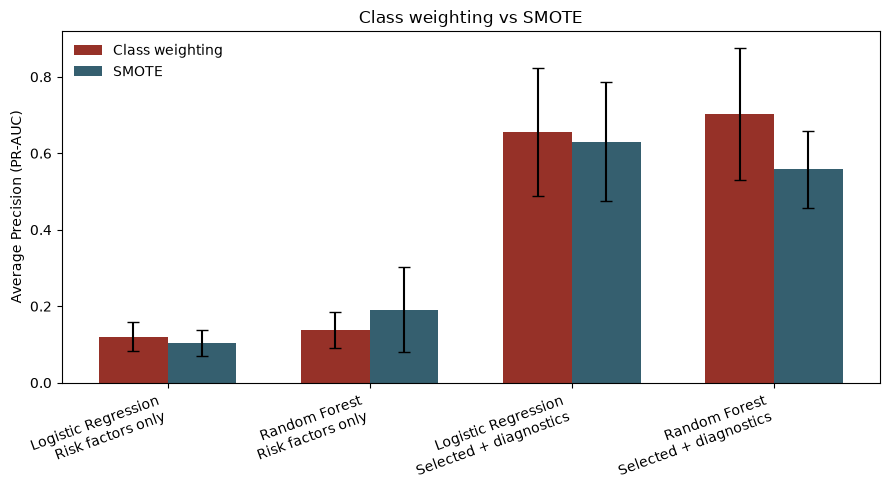

In [ ]:
plot_df = summary_df.copy()

fig, ax = plt.subplots(figsize=(9, 5))

scenarios = ["Risk factors only", "Selected + diagnostics"]
algorithms = ["Logistic Regression", "Random Forest"]
strategies = ["Class weighting", "SMOTE"]

x_positions = np.arange(len(scenarios) * len(algorithms))
bar_width = 0.34

labels = []
weighted_means, weighted_stds = [], []
smote_means, smote_stds = [], []

for scenario in scenarios:
    for algorithm in algorithms:
        labels.append(f"{algorithm}\n{scenario}")

        w = plot_df[
            (plot_df["Scenario"] == scenario) &
            (plot_df["Algorithm"] == algorithm) &
            (plot_df["Strategy"] == "Class weighting")
        ].iloc[0]

        s = plot_df[
            (plot_df["Scenario"] == scenario) &
            (plot_df["Algorithm"] == algorithm) &
            (plot_df["Strategy"] == "SMOTE")
        ].iloc[0]

        weighted_means.append(w["PR_AUC_mean"])
        weighted_stds.append(w["PR_AUC_std"])
        smote_means.append(s["PR_AUC_mean"])
        smote_stds.append(s["PR_AUC_std"])

ax.bar(
    x_positions - bar_width/2,
    weighted_means,
    bar_width,
    yerr=weighted_stds,
    capsize=4,
    label="Class weighting",
    color=CLASS_WEIGHT_COLOR,
    alpha=0.9
)

ax.bar(x_positions + bar_width/2,
    smote_means,
    bar_width,
    yerr=smote_stds,
    capsize=4,
    label="SMOTE",
    color=SMOTE_COLOR,
    alpha=0.9)

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Average Precision (PR-AUC)")
ax.set_title("Class weighting vs SMOTE")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "smote_vs_class_weighting_average_precision.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

### Interpretation

 Class-weighted and SMOTE bars largely overlap, so there is little evidence that synthetic oversampling changes our modelling conclusion.

## 8. Fold-wise PR-AUC difference

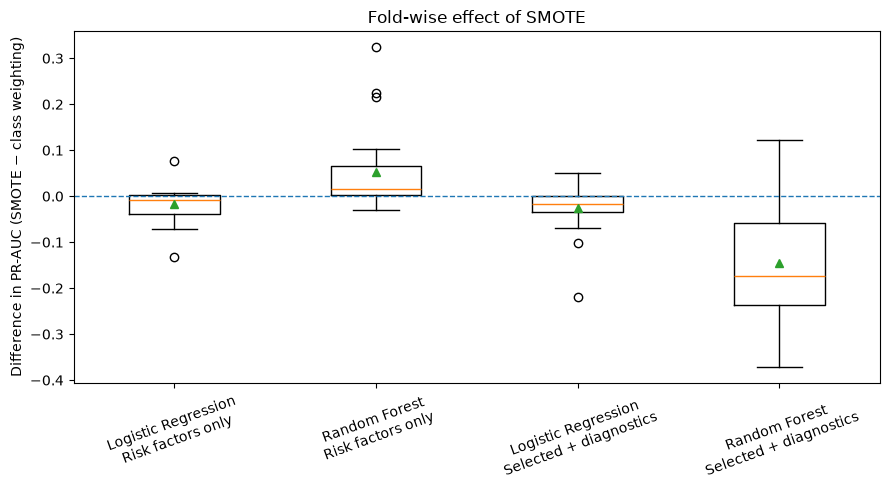

In [ ]:
delta_plot_rows = []

for scenario in ap_scores["Scenario"].unique():
    for algorithm in ap_scores["Algorithm"].unique():
        subset = ap_scores[(ap_scores["Scenario"] == scenario) &
            (ap_scores["Algorithm"] == algorithm)]

        wide = subset.pivot(index="Fold", columns="Strategy", values="Score")
        deltas = wide["SMOTE"] - wide["Class weighting"]

        for value in deltas:
            delta_plot_rows.append({"Label": f"{algorithm}\n{scenario}",
                "Delta_AP": value})

delta_df = pd.DataFrame(delta_plot_rows)

labels = delta_df["Label"].unique()
values = [delta_df.loc[delta_df["Label"] == label, "Delta_AP"].values
    for label in labels]

fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(values, tick_labels=labels, showmeans=True)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_ylabel("Difference in PR-AUC (SMOTE − class weighting)")
ax.set_title("Fold-wise effect of SMOTE")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "smote_vs_class_weighting_paired_ap_difference.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

### Interpretation

As we can see, there is a negative distribution (except for Random Forest risk factors only) that favour retaining class weighting. 

SMOTE does not consistently improve or change performance.

## 9. Secondary metrics

Average Precision remains the primary criterion, but SMOTE can alter the balance between sensitivity and precision. The following compact table therefore compares the main complementary metrics.

In [15]:
secondary_table = summary_df[["Scenario",
        "Algorithm",
        "Strategy",
        "PR_AUC_mean",
        "Recall_mean",
        "Precision_mean",
        "F1_mean",
        "Balanced_accuracy_mean",
        "MCC_mean",
        "ROC_AUC_mean"]].copy()

display(secondary_table.round(3))

,Scenario,Algorithm,Strategy,PR_AUC_mean,Recall_mean,Precision_mean,F1_mean,Balanced_accuracy_mean,MCC_mean,ROC_AUC_mean
0,Risk factors only,Logistic Regression,Class weighting,0.121,0.377,0.095,0.150,0.561,0.070,0.572
1,Risk factors only,Logistic Regression,SMOTE,0.103,0.401,0.070,0.119,0.516,0.016,0.527
2,Risk factors only,Random Forest,Class weighting,0.138,0.084,0.089,0.083,0.510,0.022,0.630
3,Risk factors only,Random Forest,SMOTE,0.191,0.104,0.189,0.128,0.534,0.091,0.645
4,Selected + diagnostics,Logistic Regression,Class weighting,0.656,0.833,0.597,0.690,0.896,0.678,0.933
5,Selected + diagnostics,Logistic Regression,SMOTE,0.631,0.826,0.616,0.700,0.894,0.687,0.933
6,Selected + diagnostics,Random Forest,Class weighting,0.703,0.851,0.680,0.751,0.911,0.740,0.967
7,Selected + diagnostics,Random Forest,SMOTE,0.559,0.773,0.566,0.648,0.865,0.632,0.952


## 10. Save the sensitivity-analysis results

These files are kept separate from the main benchmark outputs so that this notebook remains an additional robustness analysis rather than replacing the original workflow.

In [16]:
summary_df.to_csv(RESULTS_DIR / "smote_sensitivity_summary.csv", index=False)

fold_scores_df.to_csv(RESULTS_DIR / "smote_sensitivity_fold_scores.csv", index=False)
paired_comparison.to_csv(RESULTS_DIR / "smote_sensitivity_paired_AP_comparison.csv", index=False)

print("Saved:")
print(" - smote_sensitivity_summary.csv")
print(" - smote_sensitivity_fold_scores.csv")
print(" - smote_sensitivity_paired_AP_comparison.csv")

Saved:
 - smote_sensitivity_summary.csv
 - smote_sensitivity_fold_scores.csv
 - smote_sensitivity_paired_AP_comparison.csv


## Decision rule for the rest of the project

This notebook is a sensitivity analysis.

The downstream notebooks (`06`, `07`, `08`) **will not be duplicated to test SMOTE** as this analysis doesn't show a clear, consistent and practically relevant improvement in PR-AUC.

--> SMOTE produces poorer AP, so our main workflow remains as original selected training observations + class weighting.

This is particularly defensible here because many selected predictors are binary clinical or diagnostic variables. Standard SMOTE interpolates between observations and may therefore create synthetic feature combinations that may not correspond directly to observed patients.